In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
import os
import shutil
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import time

In [2]:
def afun(x, y):
    icase = 1
    if icase == 0:
        tmp = np.exp(-((x-0.)/4.)**2-((y-0.)/2)**2)
    if icase == 1:
        tmq = np.exp(-((x-0.)/3.)**2-((y-0.)/2.)**2)
        tmp = np.sin(x+y)+(x-y)**2-1.5*x+2.5*y + 1
        tmp = tmp * tmq
    if icase == 11:
        tmq = np.exp(-((x-0.)/4)**2-((y-0.)/2)**2)
        tmp = (1.5-x+x*y)**2 + (2.25-x+x*y**2)**2 + (2.625-x+x*y**3)**2
        tmp = tmp * tmq
    if icase == 2:
        tmq = np.exp(-((x-0.)/4.)**2-((y-0.)/2)**2)
        tmp = -20.*np.exp(-0.2*np.sqrt(0.5*(x**2+y**2)))-np.exp(0.5 *
                                                                (np.cos(np.pi*2*x)+np.cos(np.pi*2*y)))+np.exp(1.)+20.
        tmp = tmp * tmq
    if icase == 3:
        tmq = np.exp(-((x-0.)/4)**2-((y-0.)/2)**2)
        tmp = (1.+(x+y+1)**2 * (19.-14*x+3.*x**2-14*y + 6*x*y+3*y**2)) * \
            (30.+(2*x-3*y)**2 * (18-32*x+12*x**2 + 48*y - 36*x*y + 27*y**2))
        tmp = tmp * tmq
    if icase == 4:
        tmq = np.exp(-((x-0.)/4)**2-((y-0.)/2)**2)
        tmp = (x**2 + y-11)**2 + (x+y**2-7)**2
        tmp = tmp * tmq
    if icase == 5:
        tmq = np.exp(-((x-0.)/4)**2-((y-0.)/2)**2)
        tmp = (x**4 - 16*x**2 + 5*x + y**4 - 16*y**2 + 5*y)/2.
        tmp = tmp * tmq
    if icase == 6:
        tmp = np.cos(0.1*x) * np.cos(0.2*y)
    if icase == 7:
        tmp = np.sin(0.1*x) ** 2 + np.cos(0.2*y) ** 2
    if icase == 8:
        tmp = np.cos(0.1*x + np.sin(0.2*y))
    if icase == 9:
        tmp = np.cos(0.1*x) + np.sin(0.2*y)
    if icase == 10:
        r = np.sqrt(x**2+y**2)
        if r < 1e-10:
            tmp = 1.
        else:
            tmp = np.sin(r)/r
    return tmp

In [3]:
def append_new_line(file_name, text_to_append):
    with open(file_name, "a+") as file_object:
        file_object.seek(0)
        data = file_object.read(100)
        if len(data) > 0:
            file_object.write("\n")
        file_object.write(text_to_append)


def append_multiple_lines(file_name, lines_to_append):
    with open(file_name, "a+") as file_object:
        appendEOL = False
        file_object.seek(0)
        data = file_object.read(100)
        if len(data) > 0:
            appendEOL = True
        for line in lines_to_append:
            if appendEOL == True:
                file_object.write("\n")
            else:
                appendEOL = True
            file_object.write(line)

In [4]:
class Knnmodels:
    """
    A class that trains and manages a set of K-NN regression models using various hyperparameters (k, p).
    """
    def __init__(self, k_values, p_values):
        self.k_values = k_values
        self.p_values = p_values
        self.models = {}
        self.n_models = len(k_values) * len(p_values)

    def train(self, X_train, y_train):
        for k in self.k_values:
            for p in self.p_values:
                model_key = f"k={k}, p={p}"
                knn_reg = KNeighborsRegressor(
                    n_neighbors=k, weights='distance', p=p, algorithm='auto'
                )
                knn_reg.fit(X_train, y_train)
                self.models[model_key] = knn_reg
    
    def predict(self, X_test):
        ypred = []
        for k in self.k_values:
            for p in self.p_values:
                model_key = f"k={k}, p={p}"
                knn_reg = self.models[model_key]
                ypred.append( knn_reg.predict(X_test) )
        ypred = np.array(ypred)        
        return ypred.mean(), ypred.std()

In [5]:
def get_spiral_graph(xs, xf, ys, yf, path, xxsq, yysq):
    cseq = np.zeros(len(path), dtype=int)
    ix = []
    iy = []
    for k in range(len(path)):
        ia, ib = path[k]
        ix.append(xxsq[ia])
        iy.append(yysq[ib])
        cseq[k] = k
    plt.figure(figsize=(6, 6))
    plt.scatter(iy, ix, c=cseq, cmap='viridis', s=100, edgecolors='k', marker='o')
    # 격자 및 축 설정
    plt.gca().invert_yaxis()  # y축 반전 (2D 그리드 표시에서 중앙이 위로 오도록)
    #plt.gca().set_aspect('equal')
    plt.title('Spiral Grid Points')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.xlim(xs, xf)
    plt.ylim(ys, yf)
    plt.axis('equal')
    plt.colorbar(label='Order of Visit')  # 색상에 따라 방문 순서 표시
    plt.show()
    plt.close()

In [6]:
def spiral_grid_traversal(nx, ny):
    if nx <= 0 or ny <= 0:
        return []
    visited_points = []
    grid = [ [False for _ in range(nx)] for _ in range(ny)] 
    current_x = (nx-1)//2
    current_y = (ny-1)//2
    if False:
        dx = [0, 1, 0, -1]
        dy = [1, 0, -1, 0]
    # Such processing ensures that the measurement ends at the left and top.
    dx = [0, -1, 0, 1]
    dy = [-1, 0, 1, 0]
    direction = 0
    steps_in_direction = 1
    steps_count = 0
    total_visited = 0
    while total_visited < nx* ny:
        if 0 <= current_x < nx and 0 <= current_y < ny and not grid[current_y][current_x] :
            visited_points.append((current_x, current_y))
            grid[current_y][current_x] = True
            total_visited = total_visited +1
        if total_visited == nx*ny:
            break
        current_x = current_x + dx[direction]    
        current_y = current_y + dy[direction]
        steps_count = steps_count +1
        if steps_count == steps_in_direction:
            direction = (direction +1) %4
            steps_count = 0
            if direction % 2 == 0:
                steps_in_direction = steps_in_direction +1
    return visited_points            
    
def get_spiral(nx, ny, xs, xf, ys, yf):
    nsq = min(nx, ny)
    dxsq = (xf-xs)/float(nsq-1)
    dysq = (yf-ys)/float(nsq-1)
    xxsq = [ xs+dxsq*float(i) for i in range(nsq) ]
    yysq = [ ys+dysq*float(j) for j in range(nsq) ]
    path = spiral_grid_traversal(nsq, nsq)
    if True:
        print(path)
        print(len(path))
    xx = []
    yy = []
    for k in range(len(path)):
        ia, ib = path[k]
        x = xxsq[ia]
        y = yysq[ib]
        xx.append(x)
        yy.append(y)
    if True:
        get_spiral_graph(xs, xf, ys, yf, path, xxsq, yysq)
    return xx, yy    

In [7]:
def get_data():
    x = []
    y = []
    z = []
    afile=open('accum1.txt','r')
    for line in afile:
        x.append( float(line.split()[0]) )
        y.append( float(line.split()[1]) )
        z.append( float(line.split()[2]) )
    afile.close()
    nsamples = len(z)
    X_train = np.zeros((nsamples, 2))
    y_train = np.zeros(nsamples)
    for i in range(nsamples):
        X_train[i, 0] = x[i]
        X_train[i, 1] = y[i]
        y_train[i] = z[i]
    return X_train, y_train

[(7, 7), (7, 6), (6, 6), (6, 7), (6, 8), (7, 8), (8, 8), (8, 7), (8, 6), (8, 5), (7, 5), (6, 5), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9), (9, 8), (9, 7), (9, 6), (9, 5), (9, 4), (8, 4), (7, 4), (6, 4), (5, 4), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (5, 10), (6, 10), (7, 10), (8, 10), (9, 10), (10, 10), (10, 9), (10, 8), (10, 7), (10, 6), (10, 5), (10, 4), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (8, 11), (9, 11), (10, 11), (11, 11), (11, 10), (11, 9), (11, 8), (11, 7), (11, 6), (11, 5), (11, 4), (11, 3), (11, 2), (10, 2), (9, 2), (8, 2), (7, 2), (6, 2), (5, 2), (4, 2), (3, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (3, 12), (4, 12), (5, 12), (6, 12), (7, 12), (8, 12), (9, 12), (10, 12), (11, 12), (12, 12), (12, 11), (12, 10), (12, 9), (12, 8), (12, 7), (12, 6), (

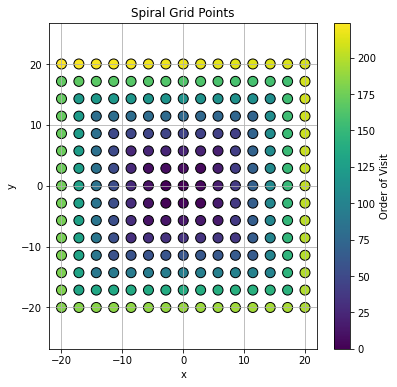

225
100
3598


In [8]:
if __name__ == "__main__":
    if os.path.isfile('accum1.txt'):
        fname = 'accum1_'+str(np.random.randint(1000000))+'.txt'
        shutil.copyfile('accum1.txt', fname)
        os.remove('accum1.txt')    
    nx = 300
    ny = 300
    xs = 0.
    xf = 1.
    ys = 0.
    yf = 1.
    xs = -20.
    xf = 20.
    ys = -20.
    yf = 20.
    dx = 0.
    dy = 0.
    if nx > 1:
        dx = (xf-xs)/float(nx-1)
    if ny > 1:
        dy = (yf-ys)/float(ny-1)
    nspiral = 0    
    if True:
        i = int(0.05* nx)
        j = int(0.05* ny)
        xx, yy = get_spiral(i, j, xs, xf, ys, yf)
#       print(len(xx), len(yy))
        for k in range(len(xx)):
            x = xx[k]
            y = yy[k]
            tmp = afun(x, y)
            astring = str(x) + ' ' + str(y) + ' ' + str(tmp)
            lines_to_append = [ astring ]
            append_multiple_lines('accum1.txt', lines_to_append)
            nspiral = nspiral +1
    print(nspiral)    
    measured = np.zeros((nx, ny), dtype=bool)
    predictable = np.zeros((nx, ny), dtype=bool)
    ncoarse = 0            
    if True:
        iskipmax = 30
        iskip = iskipmax
        for i in range(0, nx, iskip):
            x = xs
            if nx >1:
                x = xs + (xf-xs)/float(nx-1)*float(i)
            blist = []
            for j in range(0, ny, iskip):
                blist.append(j)
            if i % 2 == 1:
                blist.reverse()    
            for j in blist:
                y = ys 
                if ny > 1:
                    y = ys + (yf-ys)/float(ny-1)*float(j)
                tmp = afun(x, y)
                astring = str(x) + ' ' + str(y) + ' ' + str(tmp)
                lines_to_append = [ astring ]
                append_multiple_lines('accum1.txt', lines_to_append)
                ncoarse = ncoarse +1
                measured[i, j] = True
                predictable[i, j] = True
    print(ncoarse)        
    k_values = [ 4, 5, 6, 7, 8, 9]
    p_values = [ 1, 1.5,  2 ]
    k_values = [ 4, 5, 6, 7, 8, 9]
    p_values = [ 1,  2 ]
    trainer = Knnmodels(k_values, p_values)
    X_test = np.zeros((1,2))
    X_train, y_train = get_data()
    trainer.train(X_train, y_train)            
    # This processing prevents unnecessary predictions from being made.
    for iskip in range(iskipmax-1, 1, -1):
        for i in range(0, nx, iskip):
            x = xs
            if nx >1:
                x = xs + (xf-xs)/float(nx-1)*float(i)
            blist = []
            for j in range(0, ny, iskip):
                blist.append(j)
            if i % 2 == 1:
                blist.reverse()        
            for j in blist:
                y = ys 
                if ny > 1:
                    y = ys + (yf-ys)/float(ny-1)*float(j)
                if not predictable[i, j]:
                    X_test[0, 0] = x
                    X_test[0, 1] = y
                    tmp, tmq = trainer.predict(X_test)
                    if tmq > 1e-3 :
                        tmp = afun(x, y)
                        astring = str(x) + ' ' + str(y) + ' ' + str(tmp)
                        lines_to_append = [ astring ]
                        append_multiple_lines('accum1.txt', lines_to_append)
                        measured[i, j] = True
                        predictable[i, j] = True
                        X_train, y_train = get_data()
                        trainer.train(X_train, y_train)
                    else:
                        predictable[i, j] = True
    print(np.sum(measured))

In [9]:
i = nspiral + ncoarse + np.sum(measured)
print( nspiral, ncoarse, np.sum(measured), i, 100.0*float(i)/float(nx*ny) )
if True:
    b = np.linspace(xs, xf, nx)
    d = np.linspace(ys, yf, ny)
    B, D = np.meshgrid(b, d)
    n, m = B.shape
    print(n, m)
    nu = np.zeros((n, m))
    st = np.zeros((n, m))
    X_test = np.zeros((1, 2))
    for i in range(n):
        for j in range(m):
            X_test[0, 0] = B[i, j]
            X_test[0, 1] = D[i, j]
            y_pred, y_std = trainer.predict(X_test)
            nu[i, j] = y_pred
            st[i, j] = y_std

225 100 3598 3923 4.358888888888889
300 300


-1.209466169502742 7.3868374963329915
0.0 0.13418296323430107


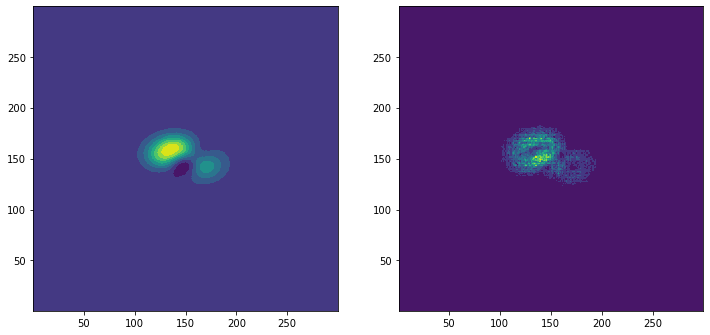

In [10]:
if True:
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
    ax1.set_aspect('equal', 'box')
    ax2.set_aspect('equal', 'box')
    amax = np.max(nu)
    amin = np.min(nu)
    print(amin, amax)
    tmz = (amax-amin)/10.
    ax1.contourf(nu, levels=np.linspace(amin, amax, 10),
                 extend='both', origin="lower")
    amax = np.max(st)
    amin = np.min(st)
    print(amin, amax)
    tmz = (amax-amin)/10.
    ax2.contourf(st, levels=np.linspace(amin, amax, 10),
                 extend='both', origin="lower")
#    plt.savefig('mean_std1.pdf')
    plt.show()
    plt.close()

In [11]:
if True:
    xx = []
    yy = []
    afile=open('accum1.txt','r')
    for line in afile:
        xx.append( float(line.split()[0]) )
        yy.append( float(line.split()[1]) )
    afile.close()
    print(len(xx), nx*ny, 100.0*float(len(xx))/float(nx*ny))
    coords = np.zeros((len(yy),2))
    for i in range(len(yy)):
        coords[i, 0] = xx[i]
        coords[i, 1] = yy[i]

3823 90000 4.247777777777777


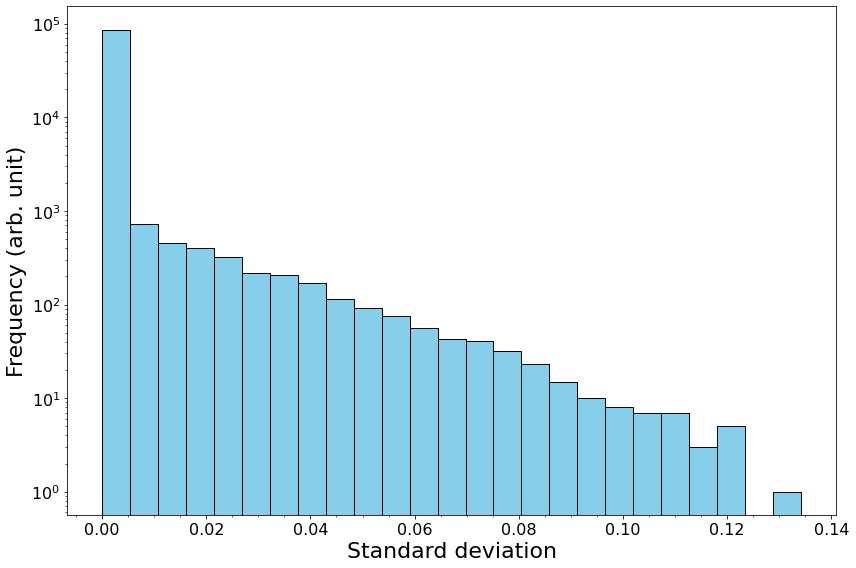

0.0009990831114475348 0.006101057032676697


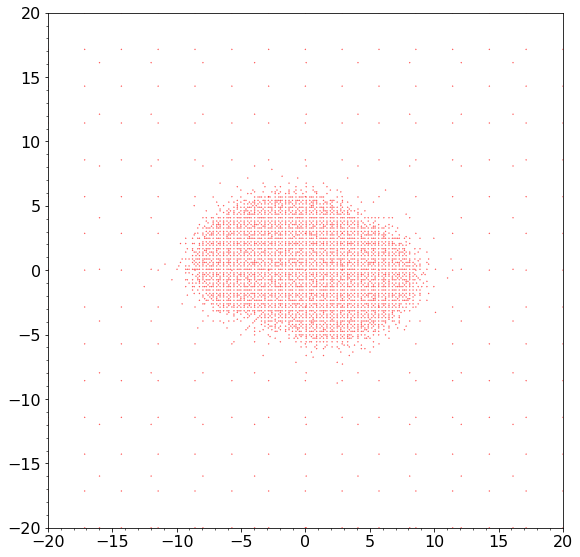

In [12]:
if True:
    result = st.flatten()
    fig = plt.figure(figsize=(12, 8))
    plt.rcParams["xtick.minor.visible"] = True
    plt.rcParams["ytick.minor.visible"] = True
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.hist(result, bins=25, color='skyblue', edgecolor='black')
    plt.xlabel('Standard deviation', fontsize=22)
    plt.ylabel('Frequency (arb. unit)', fontsize=22)
    plt.yscale('log')
    plt.xticks(fontsize=16)
#    plt.yticks(fontsize=19, rotation=0)
#    plt.tick_params(axis='both', which='major', labelsize=12)
#    plt.rc('xtick',labelsize=18)
#    plt.rc('ytick',labelsize=22)
    plt.tight_layout()
#    plt.savefig('sig_dist_knn1.pdf')
    plt.show()
    plt.close()
    print(np.mean(result), np.std(result))
if True:
    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    ax.set_aspect(1.)
    plt.xlim(xs, xf)
    plt.ylim(ys, yf)
    plt.scatter(coords[:, 0], coords[:, 1], s=0.1,
                facecolors='none', edgecolors='r')
    plt.tight_layout()
#    plt.savefig("sampled_knn1.pdf")
    plt.show()
    plt.close()